# 03 · D3TaLES 固定数据划分

本 Notebook 为 `D3TaLES-Reduction-v1` 生成两个固定划分：以 Bemis–Murcko scaffold 为单位的主划分，以及按分子随机打乱的辅助划分。两者都使用 80%/10%/10% 和固定种子 42。

本 Notebook 不计算描述符、不构建图、不训练模型。请从上到下逐格运行，任何质量检查失败时立即停止。

## 单元格 1：导入依赖并定位项目目录

作用：导入路径、哈希、JSON、数据分析和绘图工具，并自动定位项目根目录。划分过程只依赖 Python、NumPy 和 pandas。

In [1]:
# 标准库：路径、哈希、JSON 和环境版本
from pathlib import Path
import hashlib
import json
import platform

# 数据处理与可视化
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 使用标准 Bemis–Murcko 方法重新生成不含手性的 scaffold
from rdkit.Chem.Scaffolds import MurckoScaffold

# 支持从项目根目录或 notebooks 目录启动
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == 'notebooks' else CURRENT_DIR

print('Python:', platform.python_version())
print('NumPy:', np.__version__)
print('pandas:', pd.__version__)
print('项目根目录:', PROJECT_ROOT)

Python: 3.10.21
NumPy: 1.26.4
pandas: 2.3.3
项目根目录: E:\desktop\myJCIM


## 单元格 2：设置输入、输出和划分参数

作用：指定清洗数据路径、输出路径、80%/10%/10% 比例和随机种子 42。训练时的五个随机种子不会改变这里固定的数据划分。

In [2]:
# 输入与输出路径
CLEAN_CSV = PROJECT_ROOT / 'data' / 'processed' / 'd3tales_reduction_neutral_v1.csv'
SPLIT_DIR = PROJECT_ROOT / 'data' / 'splits'
REPORT_DATA_DIR = PROJECT_ROOT / 'reports' / 'data'
REPORT_FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figures'

# 固定划分配置；三项之和必须等于1
TRAIN_FRACTION = 0.80
VALID_FRACTION = 0.10
TEST_FRACTION = 0.10
SPLIT_SEED = 42
DATASET_VERSION = 'D3TaLES-Reduction-v1'

assert np.isclose(TRAIN_FRACTION + VALID_FRACTION + TEST_FRACTION, 1.0)
if not CLEAN_CSV.exists():
    raise FileNotFoundError(f'没有找到清洗数据: {CLEAN_CSV}')

for output_dir in [SPLIT_DIR, REPORT_DATA_DIR, REPORT_FIGURE_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

print('清洗数据:', CLEAN_CSV)
print('划分比例:', TRAIN_FRACTION, VALID_FRACTION, TEST_FRACTION)
print('固定种子:', SPLIT_SEED)

清洗数据: E:\desktop\myJCIM\data\processed\d3tales_reduction_neutral_v1.csv
划分比例: 0.8 0.1 0.1
固定种子: 42


## 单元格 3：读取并验证清洗数据

作用：计算清洗文件的 SHA256，读取 30,102 个分子，并验证数据版本、ID、Canonical SMILES、目标值和 scaffold 字段。

In [3]:
# 计算清洗文件校验值，后续写入划分元数据
sha256 = hashlib.sha256()
with CLEAN_CSV.open('rb') as file_handle:
    for chunk in iter(lambda: file_handle.read(1024 * 1024), b''):
        sha256.update(chunk)
clean_sha256 = sha256.hexdigest()

# keep_default_na=False 保留无环分子的空 scaffold 字符串
df = pd.read_csv(CLEAN_CSV, keep_default_na=False, low_memory=False)
required_columns = [
    'dataset_id', 'dataset_version', 'canonical_smiles',
    'reduction_potential', 'murcko_scaffold'
]
missing_columns = sorted(set(required_columns) - set(df.columns))
assert not missing_columns, f'缺少划分必需字段: {missing_columns}'
assert len(df) == 30102, f'样本数异常: {len(df)}'
assert df['dataset_id'].is_unique, 'dataset_id不唯一'
assert df['canonical_smiles'].is_unique, 'Canonical SMILES不唯一'
assert df['reduction_potential'].notna().all(), '目标值存在缺失'
assert df['dataset_version'].eq(DATASET_VERSION).all(), '数据版本不一致'

print('清洗文件SHA256:', clean_sha256)
print('数据形状:', df.shape)
print('唯一scaffold（含空scaffold）:', df['murcko_scaffold'].nunique(dropna=False))
print('空scaffold分子:', df['murcko_scaffold'].eq('').sum())

清洗文件SHA256: 377c6cee92531d0a93e24b4644a118de54d88ae2b1915ff15564c70a80498705
数据形状: (30102, 14)
唯一scaffold（含空scaffold）: 15956
空scaffold分子: 7


## 单元格 4：检查 scaffold 分组规模

作用：从 Canonical SMILES 重新生成不含手性的标准 Bemis–Murcko scaffold，再统计每个 scaffold 包含多少分子。空 scaffold 被视为同一个 `__EMPTY_SCAFFOLD__` 组，确保无环分子不会跨集合泄漏。

In [4]:
# 标准 Scaffold Split 忽略手性，避免同一拓扑骨架的立体异构体跨集合
def to_achiral_scaffold(canonical_smiles):
    scaffold = MurckoScaffold.MurckoScaffoldSmiles(
        smiles=canonical_smiles,
        includeChirality=False,
    )
    return scaffold if scaffold else '__EMPTY_SCAFFOLD__'

# 原始murcko_scaffold字段保留用于追溯，scaffold_key专门用于严格划分
df['scaffold_key'] = df['canonical_smiles'].map(to_achiral_scaffold)
scaffold_sizes = (
    df.groupby('scaffold_key')
    .size()
    .sort_values(ascending=False)
    .rename('molecule_count')
)

scaffold_audit = pd.Series({
    'molecules': len(df),
    'scaffold_groups': len(scaffold_sizes),
    'single_molecule_scaffolds': int(scaffold_sizes.eq(1).sum()),
    'largest_scaffold_group': int(scaffold_sizes.max()),
    'empty_scaffold_group_size': int(scaffold_sizes.get('__EMPTY_SCAFFOLD__', 0)),
})
display(scaffold_audit)
scaffold_sizes.head(20).to_frame()

molecules                    30102
scaffold_groups              15576
single_molecule_scaffolds    12688
largest_scaffold_group        1696
empty_scaffold_group_size        7
dtype: int64

,molecule_count
scaffold_key,
c1ccccc1,1696
c1ccncc1,318
c1ccsc1,206
c1cscn1,163
c1cn[nH]c1,157
c1ccc(N(c2ccccc2)c2ccccc2)cc1,148
O=C1C=CC(=O)c2ccccc21,141
C1=CC(c2ccccc2)C=CN1,130
C1=CC2Nc3ccccc3SC2C=C1,122


## 单元格 5：定义确定性的 Scaffold Split

作用：将完整 scaffold 组按规模从大到小分配到 train、valid 和 test。种子只用于打破相同规模 scaffold 的排序平局；同一个 scaffold 永远只进入一个集合。

In [6]:
# 返回每个dataset_id对应的split；不使用目标值决定分配
def make_scaffold_split(frame, seed, train_fraction, valid_fraction):
    scaffold_groups = [
        (scaffold, group['dataset_id'].tolist())
        for scaffold, group in frame.groupby('scaffold_key', sort=False)
    ]

    # 先随机打乱，再稳定地按组大小降序排列，使相同大小组的顺序可复现
    rng = np.random.default_rng(seed)
    rng.shuffle(scaffold_groups)
    scaffold_groups.sort(key=lambda item: len(item[1]), reverse=True)

    total = len(frame)
    train_limit = int(total * train_fraction)
    valid_limit = int(total * valid_fraction)
    split_by_id = {}
    train_count = 0
    valid_count = 0

    # 标准贪心策略：优先填充train，再填充valid，剩余完整scaffold进入test
    for _, molecule_ids in scaffold_groups:
        group_size = len(molecule_ids)
        if train_count + group_size <= train_limit:
            split_name = 'train'
            train_count += group_size
        elif valid_count + group_size <= valid_limit:
            split_name = 'valid'
            valid_count += group_size
        else:
            split_name = 'test'

        for molecule_id in molecule_ids:
            split_by_id[molecule_id] = split_name

    return pd.Series(split_by_id, name='split')

print('Scaffold Split函数已定义，尚未保存结果。')

Scaffold Split函数已定义，尚未保存结果。


## 单元格 6：生成 Scaffold Split 主划分

作用：运行固定的 scaffold 贪心划分，并统计每个集合的分子数量、比例和 scaffold 数量。由于完整 scaffold 不能拆分，比例允许存在很小偏差。

In [7]:
# 生成dataset_id到split的映射，再合并回数据表
scaffold_assignment = make_scaffold_split(
    df,
    seed=SPLIT_SEED,
    train_fraction=TRAIN_FRACTION,
    valid_fraction=VALID_FRACTION,
)
scaffold_split = df.merge(
    scaffold_assignment.rename_axis('dataset_id').reset_index(),
    on='dataset_id',
    how='left',
    validate='one_to_one',
)

scaffold_counts = scaffold_split['split'].value_counts().reindex(['train', 'valid', 'test'])
scaffold_group_counts = (
    scaffold_split.groupby('split')['scaffold_key']
    .nunique()
    .reindex(['train', 'valid', 'test'])
)
scaffold_overview = pd.DataFrame({
    'molecules': scaffold_counts,
    'fraction': scaffold_counts / len(scaffold_split),
    'scaffolds': scaffold_group_counts,
})
scaffold_overview

,molecules,fraction,scaffolds
split,,,
train,24081,0.799980,9555
valid,3010,0.099993,3010
test,3011,0.100027,3011


## 单元格 7：验证 Scaffold Split 无泄漏

作用：检查所有分子恰好出现一次、三个集合均非空，并验证 train、valid、test 之间没有任何 scaffold 交集。

In [8]:
# 基础完整性检查
assert scaffold_split['split'].notna().all(), '存在未分配的分子'
assert scaffold_split['dataset_id'].is_unique, '划分后dataset_id重复'
assert set(scaffold_split['split']) == {'train', 'valid', 'test'}, '划分集合不完整'
assert len(scaffold_split) == len(df), '划分前后样本数不一致'

# scaffold集合必须两两不相交，这是主划分最关键的质量检查
scaffolds_by_split = {
    split_name: set(group['scaffold_key'])
    for split_name, group in scaffold_split.groupby('split')
}
train_valid_overlap = scaffolds_by_split['train'] & scaffolds_by_split['valid']
train_test_overlap = scaffolds_by_split['train'] & scaffolds_by_split['test']
valid_test_overlap = scaffolds_by_split['valid'] & scaffolds_by_split['test']

assert not train_valid_overlap, 'train与valid存在scaffold泄漏'
assert not train_test_overlap, 'train与test存在scaffold泄漏'
assert not valid_test_overlap, 'valid与test存在scaffold泄漏'

print('Scaffold Split质量检查通过。')
print('train-valid scaffold交集:', len(train_valid_overlap))
print('train-test scaffold交集:', len(train_test_overlap))
print('valid-test scaffold交集:', len(valid_test_overlap))

Scaffold Split质量检查通过。
train-valid scaffold交集: 0
train-test scaffold交集: 0
valid-test scaffold交集: 0


## 单元格 8：生成 Random Split 辅助划分

作用：使用相同种子随机打乱全部唯一分子，并按照精确的 80%/10%/10% 数量切分。Random Split 只用于辅助比较。

In [9]:
# 使用NumPy的独立随机数生成器，避免受其他代码中的随机状态影响
rng = np.random.default_rng(SPLIT_SEED)
permuted_indices = rng.permutation(len(df))
train_end = int(len(df) * TRAIN_FRACTION)
valid_end = train_end + int(len(df) * VALID_FRACTION)

random_labels = np.empty(len(df), dtype=object)
random_labels[permuted_indices[:train_end]] = 'train'
random_labels[permuted_indices[train_end:valid_end]] = 'valid'
random_labels[permuted_indices[valid_end:]] = 'test'

random_split = df.copy()
random_split['split'] = random_labels
random_overview = (
    random_split['split'].value_counts()
    .reindex(['train', 'valid', 'test'])
    .to_frame('molecules')
)
random_overview['fraction'] = random_overview['molecules'] / len(random_split)
random_overview

,molecules,fraction
split,,
train,24081,0.799980
valid,3010,0.099993
test,3011,0.100027


## 单元格 9：验证 Random Split 完整性

作用：验证随机划分覆盖全部分子、没有重复 ID、三个集合互不重叠。Random Split 不要求 scaffold 无交集，因为它正是随机分子级对照。

In [10]:
# 检查随机划分的ID集合两两不相交且并集等于原始数据
ids_by_random_split = {
    split_name: set(group['dataset_id'])
    for split_name, group in random_split.groupby('split')
}
assert random_split['dataset_id'].is_unique, 'Random Split中dataset_id重复'
assert set(random_split['split']) == {'train', 'valid', 'test'}, 'Random Split集合不完整'
assert len(random_split) == len(df), 'Random Split前后样本数不一致'
assert not (ids_by_random_split['train'] & ids_by_random_split['valid'])
assert not (ids_by_random_split['train'] & ids_by_random_split['test'])
assert not (ids_by_random_split['valid'] & ids_by_random_split['test'])
assert set().union(*ids_by_random_split.values()) == set(df['dataset_id'])

print('Random Split质量检查通过。')

Random Split质量检查通过。


## 单元格 10：比较两个划分中的目标统计

作用：分别计算 train、valid、test 的样本量、目标均值、标准差和范围。Scaffold Split 不使用目标值做分层，因此各集合分布不必完全相同。

In [11]:
# 统一生成划分统计，便于后续写入论文数据章节
def summarize_split(frame, method):
    summary = (
        frame.groupby('split')['reduction_potential']
        .agg(['count', 'mean', 'std', 'min', 'max'])
        .reindex(['train', 'valid', 'test'])
        .reset_index()
    )
    summary.insert(0, 'method', method)
    summary['fraction'] = summary['count'] / len(frame)
    return summary

split_summary = pd.concat([
    summarize_split(scaffold_split, 'scaffold'),
    summarize_split(random_split, 'random'),
], ignore_index=True)
split_summary

,method,split,count,mean,std,min,max,fraction
0,scaffold,train,24081,6.809240,1.050899,3.418,11.00,0.799980
1,scaffold,valid,3010,6.746121,0.979505,3.530,10.69,0.099993
2,scaffold,test,3011,6.771600,1.008574,4.204,10.99,0.100027
3,random,train,24081,6.798644,1.040650,3.418,11.00,0.799980
4,random,valid,3010,6.801117,1.034230,4.438,10.99,0.099993
5,random,test,3011,6.801367,1.040635,3.940,10.99,0.100027


## 单元格 11：绘制划分后的目标分布

作用：分别展示 Scaffold Split 和 Random Split 中三个集合的目标分布。该图用于判断不同划分带来的分布差异，不用于修改划分。

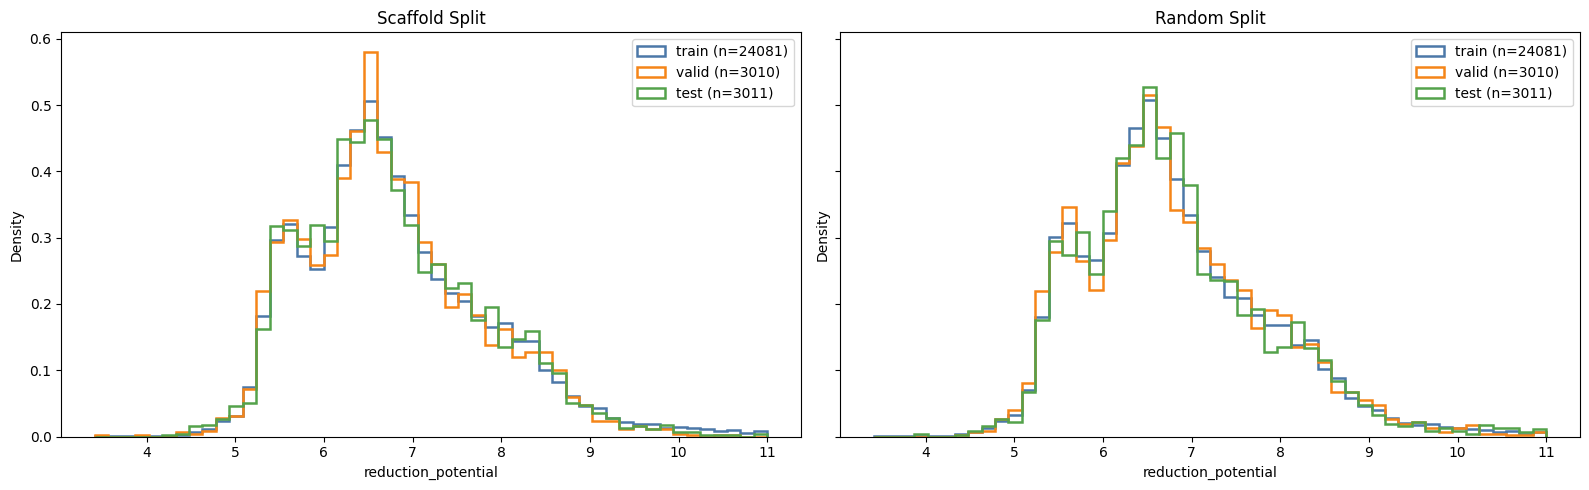

图片已保存: E:\desktop\myJCIM\reports\figures\d3tales_split_distributions_v1.png


In [12]:
# 所有子图使用相同分箱，便于直接比较
bins = np.linspace(df['reduction_potential'].min(), df['reduction_potential'].max(), 51)
colors = {'train': '#4C78A8', 'valid': '#F58518', 'test': '#54A24B'}
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)

for ax, (method_name, split_frame) in zip(
    axes, [('Scaffold Split', scaffold_split), ('Random Split', random_split)]
):
    for split_name in ['train', 'valid', 'test']:
        values = split_frame.loc[split_frame['split'].eq(split_name), 'reduction_potential']
        ax.hist(
            values, bins=bins, density=True, histtype='step', linewidth=1.8,
            color=colors[split_name], label=f'{split_name} (n={len(values)})'
        )
    ax.set_title(method_name)
    ax.set_xlabel('reduction_potential')
    ax.set_ylabel('Density')
    ax.legend()

fig.tight_layout()
figure_path = REPORT_FIGURE_DIR / 'd3tales_split_distributions_v1.png'
fig.savefig(figure_path, dpi=200, bbox_inches='tight')
plt.show()
print('图片已保存:', figure_path)

## 单元格 12：保存固定划分和元数据

作用：保存两个轻量级划分文件、统计表和配置元数据。划分文件只包含追踪训练所需的 ID、结构键和 split，不复制完整数据集。

In [13]:
# 固定输出文件名；后续所有模型必须复用这些文件
scaffold_path = SPLIT_DIR / 'scaffold_seed42.csv'
random_path = SPLIT_DIR / 'random_seed42.csv'
summary_path = REPORT_DATA_DIR / 'd3tales_split_summary_v1.csv'
metadata_path = REPORT_DATA_DIR / 'd3tales_split_metadata_v1.json'

split_columns = [
    'dataset_id', 'canonical_smiles', 'murcko_scaffold', 'scaffold_key', 'split'
]
scaffold_split[split_columns].to_csv(scaffold_path, index=False)
random_split[split_columns].to_csv(random_path, index=False)
split_summary.to_csv(summary_path, index=False)

split_metadata = {
    'dataset_version': DATASET_VERSION,
    'clean_file': str(CLEAN_CSV),
    'clean_file_sha256': clean_sha256,
    'total_molecules': int(len(df)),
    'fractions': {
        'train': TRAIN_FRACTION, 'valid': VALID_FRACTION, 'test': TEST_FRACTION
    },
    'seed': SPLIT_SEED,
    'primary_split': 'scaffold',
    'auxiliary_split': 'random',
    'scaffold_definition': 'Bemis-Murcko includeChirality=False',
    'scaffold_algorithm': 'size_descending_greedy_train_then_valid_then_test',
    'empty_scaffold_policy': 'all_empty_scaffolds_share_one_group',
    'scaffold_counts': {key: int(value) for key, value in scaffold_counts.items()},
    'random_counts': {
        key: int(value) for key, value in random_overview['molecules'].items()
    },
    'scaffold_overlap': {
        'train_valid': len(train_valid_overlap),
        'train_test': len(train_test_overlap),
        'valid_test': len(valid_test_overlap),
    },
    'python_version': platform.python_version(),
    'numpy_version': np.__version__,
    'pandas_version': pd.__version__,
}
with metadata_path.open('w', encoding='utf-8') as file_handle:
    json.dump(split_metadata, file_handle, ensure_ascii=False, indent=2)

print('Scaffold Split:', scaffold_path)
print('Random Split:', random_path)
print('划分统计:', summary_path)
print('划分元数据:', metadata_path)

Scaffold Split: E:\desktop\myJCIM\data\splits\scaffold_seed42.csv
Random Split: E:\desktop\myJCIM\data\splits\random_seed42.csv
划分统计: E:\desktop\myJCIM\reports\data\d3tales_split_summary_v1.csv
划分元数据: E:\desktop\myJCIM\reports\data\d3tales_split_metadata_v1.json


## 单元格 13：从磁盘重新读取并最终验证

作用：重新读取两个已保存划分，验证行数、ID 唯一性、覆盖范围以及 Scaffold Split 的骨架零交集。完成后把输出和分布图发给我。

In [14]:
# 重新读取磁盘产物，而不是继续信任内存对象
saved_scaffold = pd.read_csv(scaffold_path, keep_default_na=False)
saved_random = pd.read_csv(random_path, keep_default_na=False)

for split_name, saved_frame in [('scaffold', saved_scaffold), ('random', saved_random)]:
    assert len(saved_frame) == len(df), f'{split_name}保存后行数异常'
    assert saved_frame['dataset_id'].is_unique, f'{split_name}保存后ID重复'
    assert set(saved_frame['dataset_id']) == set(df['dataset_id']), f'{split_name}覆盖不完整'
    assert set(saved_frame['split']) == {'train', 'valid', 'test'}

saved_scaffolds = {
    name: set(group['scaffold_key'])
    for name, group in saved_scaffold.groupby('split')
}
assert not (saved_scaffolds['train'] & saved_scaffolds['valid'])
assert not (saved_scaffolds['train'] & saved_scaffolds['test'])
assert not (saved_scaffolds['valid'] & saved_scaffolds['test'])

final_split_check = pd.DataFrame({
    'scaffold_count': saved_scaffold['split'].value_counts(),
    'random_count': saved_random['split'].value_counts(),
}).reindex(['train', 'valid', 'test'])
print('磁盘文件最终验证通过；Scaffold Split骨架交集为0。')
final_split_check

磁盘文件最终验证通过；Scaffold Split骨架交集为0。


,scaffold_count,random_count
split,,
train,24081,24081
valid,3010,3010
test,3011,3011
